In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset/Validation/Fake/fake_12723.jpg
/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset/Validation/Fake/fake_13601.jpg
/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset/Validation/Fake/fake_1068.jpg
/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset/Validation/Fake/fake_16385.jpg
/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset/Validation/Fake/fake_3016.jpg
/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset/Validation/Fake/fake_15715.jpg
/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset/Validation/Fake/fake_19044.jpg
/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset/Validation/Fake/fake_18989.jpg
/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset/Validation/Fake/fake_8983.jpg
/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset/Validation/Fake/fake_11540.jpg
/kaggle/input

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm # PyTorch Image Models library
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc
import torch.nn.functional as F
from PIL import Image

# Explicitly target the T4 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Computation Device: {device}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Computation Device: cuda
GPU Name: Tesla T4


In [5]:
import os

# Walk through all directories in Kaggle's input folder
for root, dirs, files in os.walk("/kaggle/input/"):
    # Look for the exact folder named "Train" (case-sensitive)
    if "Train" in dirs:
        print("✅ FOUND IT!")
        print(f"Your EXACT base_dir is:\nbase_dir = '{root}'")
        break
else:
    print("❌ Couldn't find a folder named 'Train'. Let me know if it prints this!")

✅ FOUND IT!
Your EXACT base_dir is:
base_dir = '/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset'


In [6]:
# Hyperparameters optimized for Kaggle GPU T4 (16GB VRAM)
BATCH_SIZE = 128 
IMG_SIZE = 224
EPOCHS = 20 
PATIENCE = 3

# Data augmentation for training to prevent overfitting
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Standard transforms for validation/testing
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

base_dir = "/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset"
train_dir = f"{base_dir}/Train"
val_dir = f"{base_dir}/Validation"
test_dir = f"{base_dir}/Test"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

# Dataloaders - Now utilizing the explicit Validation split!
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Classes: {train_dataset.classes} (0 = Fake, 1 = Real)")
print(f"Total Training Samples: {len(train_dataset):,}")
print(f"Total Validation Samples: {len(val_dataset):,}")
print(f"Total Testing Samples: {len(test_dataset):,}")

Classes: ['Fake', 'Real'] (0 = Fake, 1 = Real)
Total Training Samples: 140,002
Total Validation Samples: 39,428
Total Testing Samples: 10,905


In [7]:
# Initialize EfficientNet-B3
# pretrained=True downloads weights via Kaggle's internet connection for transfer learning
model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=2)
model = model.to(device)

# Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Initialize Gradient Scaler for Automatic Mixed Precision (AMP)
scaler = torch.amp.GradScaler('cuda')

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

In [8]:
train_losses, val_accuracies = [], []
best_val_acc = 0.0
epochs_no_improve = 0

print(f"Starting training for up to {EPOCHS} epochs with patience {PATIENCE}...\n")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    # --- Training Phase ---
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        train_pbar.set_postfix({'Loss': f"{loss.item():.4f}"})
        
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- Validation Phase (Using val_loader) ---
    model.eval()
    correct, total = 0, 0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Validate]")
    
    with torch.no_grad():
        for inputs, labels in val_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            current_acc = 100 * correct / total
            val_pbar.set_postfix({'Acc': f"{current_acc:.2f}%"})
            
    accuracy = 100 * correct / total
    val_accuracies.append(accuracy)
    
    print(f"-> End of Epoch {epoch+1} | Avg Train Loss: {avg_train_loss:.4f} | Val Accuracy: {accuracy:.2f}%")
    
    # --- EARLY STOPPING LOGIC ---
    if accuracy > best_val_acc:
        best_val_acc = accuracy
        epochs_no_improve = 0
        torch.save(model.state_dict(), '/kaggle/working/deepfake_image_detector_b3_best.pth')
        print(f"   [+] Accuracy improved to {accuracy:.2f}%. Model saved!\n")
    else:
        epochs_no_improve += 1
        print(f"   [-] No improvement for {epochs_no_improve} epoch(s).\n")
        
        if epochs_no_improve >= PATIENCE:
            print(f"[!] EARLY STOPPING TRIGGERED! Training halted at Epoch {epoch+1}.")
            print(f"[!] The best model achieved {best_val_acc:.2f}% accuracy and is saved in /kaggle/working/.")
            break

Starting training for up to 20 epochs with patience 3...



Epoch 1/20 [Validate]: 100%|██████████| 309/309 [02:03<00:00,  2.50it/s, Acc=97.78%]


-> End of Epoch 1 | Avg Train Loss: 0.0997 | Val Accuracy: 97.78%
   [+] Accuracy improved to 97.78%. Model saved!



Epoch 2/20 [Validate]: 100%|██████████| 309/309 [01:18<00:00,  3.93it/s, Acc=98.18%]


-> End of Epoch 2 | Avg Train Loss: 0.0365 | Val Accuracy: 98.18%
   [+] Accuracy improved to 98.18%. Model saved!



...

-> End of Epoch 6 | Avg Train Loss: 0.0292 | Val Accuracy: 98.30%
   [-] No improvement for 1 epoch(s).



Epoch 7/20 [Validate]: 100%|██████████| 309/309 [01:15<00:00,  4.10it/s, Acc=97.45%]


-> End of Epoch 7 | Avg Train Loss: 0.0269 | Val Accuracy: 97.45%
   [-] No improvement for 2 epoch(s).



Epoch 8/20 [Validate]: 100%|██████████| 309/309 [01:16<00:00,  4.05it/s, Acc=98.42%]

-> End of Epoch 8 | Avg Train Loss: 0.0248 | Val Accuracy: 98.42%
   [-] No improvement for 3 epoch(s).

[!] EARLY STOPPING TRIGGERED! Training halted at Epoch 8.
[!] The best model achieved 98.48% accuracy and is saved in /kaggle/working/.


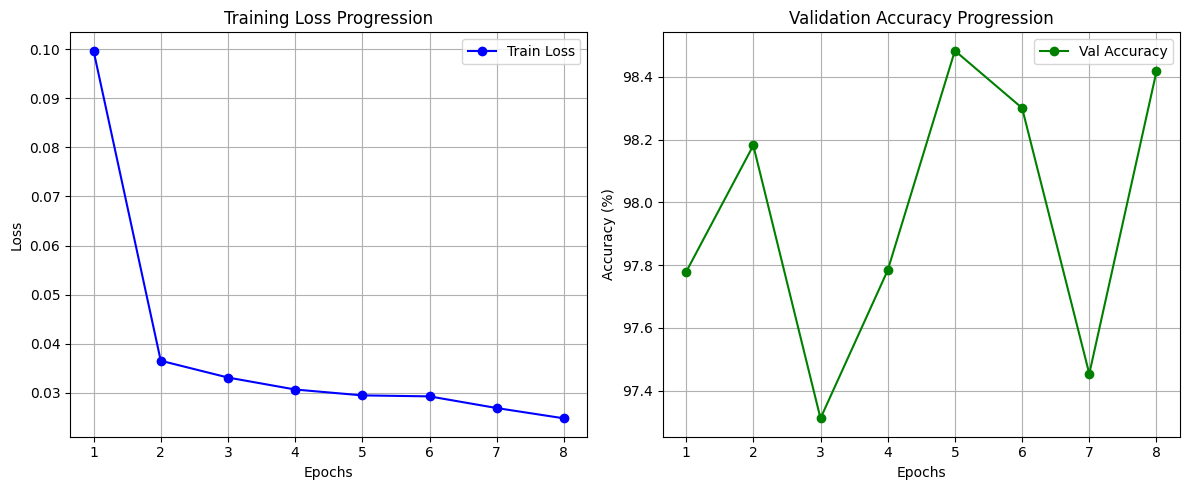

In [9]:
actual_epochs = len(train_losses)
epochs_range = range(1, actual_epochs + 1)

plt.figure(figsize=(12, 5))

# Left Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, marker='o', color='b', label='Train Loss')
plt.title('Training Loss Progression')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.grid(True)
plt.legend()

# Right Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_accuracies, marker='o', color='g', label='Val Accuracy')
plt.title('Validation Accuracy Progression')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs_range)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Extracting Test Metrics: 100%|██████████| 86/86 [00:41<00:00,  2.10it/s]



            DEEPFAKE DETECTOR TEST PERFORMANCE
Overall Accuracy : 89.23%
Precision        : 0.8402 (When flagged as fake, how often is it correct?)
Recall (Sens.)   : 0.9707 (What % of actual deepfakes were caught?)
F1-Score         : 0.9007 (Balanced harmonic mean)

Detailed Classification Report:
              precision    recall  f1-score   support

        Fake       0.84      0.97      0.90      5492
        Real       0.96      0.81      0.88      5413

    accuracy                           0.89     10905
   macro avg       0.90      0.89      0.89     10905
weighted avg       0.90      0.89      0.89     10905



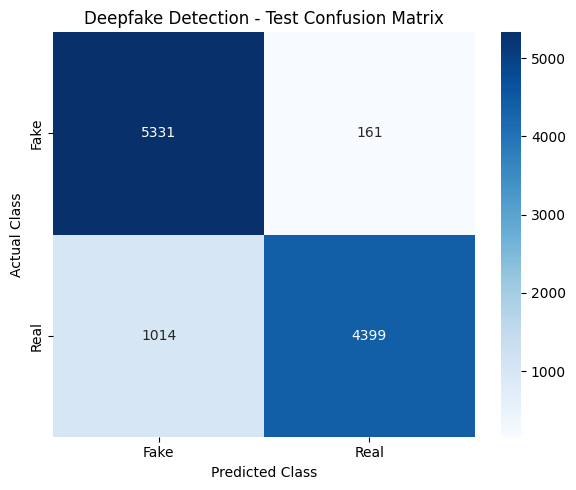

In [10]:
# Load the best weights before testing to ensure we aren't testing an overfitted epoch
model.load_state_dict(torch.load('/kaggle/working/deepfake_image_detector_b3_best.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Extracting Test Metrics"):
        inputs = inputs.to(device)
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

# pos_label=0 targets the 'Fake' folder
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label=0, average='binary')
recall = recall_score(y_true, y_pred, pos_label=0, average='binary')
f1 = f1_score(y_true, y_pred, pos_label=0, average='binary')

print("\n" + "="*50)
print("            DEEPFAKE DETECTOR TEST PERFORMANCE")
print("="*50)
print(f"Overall Accuracy : {accuracy * 100:.2f}%")
print(f"Precision        : {precision:.4f} (When flagged as fake, how often is it correct?)")
print(f"Recall (Sens.)   : {recall:.4f} (What % of actual deepfakes were caught?)")
print(f"F1-Score         : {f1:.4f} (Balanced harmonic mean)")
print("="*50)

print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_dataset.classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=test_dataset.classes, 
            yticklabels=test_dataset.classes)
plt.title('Deepfake Detection - Test Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

Extracting Test Probabilities: 100%|██████████| 86/86 [00:20<00:00,  4.14it/s]


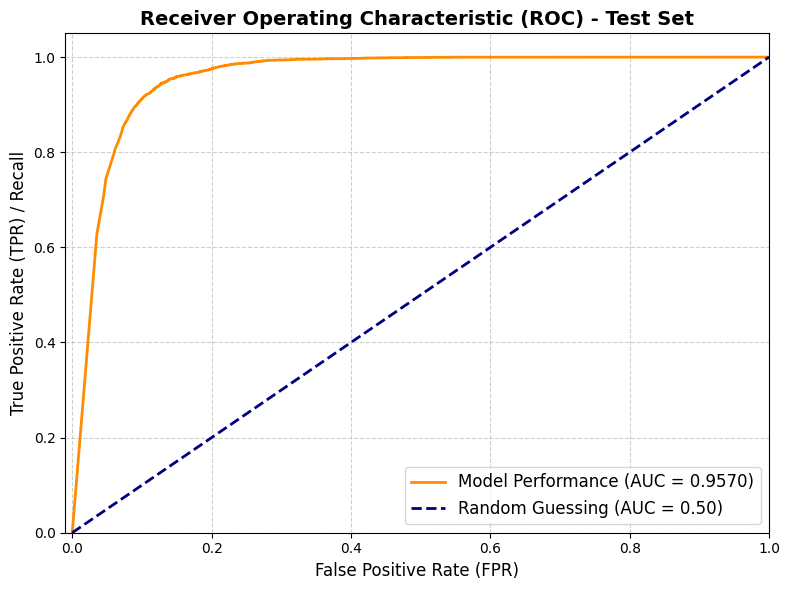

In [11]:
model.eval()
all_probs = []
all_labels_roc = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Extracting Test Probabilities"):
        inputs = inputs.to(device)
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            
        probs = F.softmax(outputs, dim=1)
        class_0_probs = probs[:, 0].cpu().numpy() # Extract FAKE probabilities
        
        all_probs.extend(class_0_probs)
        all_labels_roc.extend(labels.cpu().numpy())

fpr, tpr, thresholds = roc_curve(all_labels_roc, all_probs, pos_label=0)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Model Performance (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.50)')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR) / Recall', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) - Test Set', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()